# GH200 throughput sweep — preliminary visualization
Data: `_runs/20260827-throughput-gh200-dump/` (derived CSVs; raw JSONLs in the sibling dirs).
Campaign + pitfalls: `_claude/20260827-110000-RESULTS-…` and `-113000-HANDOFF-…`.

**House rules baked in here:** figures use the **v2-i50 release dataset only**; kernel arms are
never averaged (grouped by the pre-decoded `arm` column); B=1 cells are a *launch-bound regime*
(quote ≈ratios, never a third digit); trunk mode is the architecture story (no vocab-head confound).

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
DUMP = Path("../_runs/20260827-throughput-gh200-dump")
flat = pd.read_csv(DUMP / "flat_all_records.csv")
for c in ("oom", "unsupported"):
    flat[c] = flat[c].fillna(False).astype(bool)
v2 = flat[(flat.dataset == "v2-i50") & ~flat.oom & ~flat.unsupported].copy()
tier1 = pd.read_csv(DUMP / "tier1_ratios.csv")
arms = pd.read_csv(DUMP / "arms_2x2.csv")
stab = pd.read_csv(DUMP / "stability.csv")
msum = pd.read_csv(DUMP / "model_summary.csv")
ident = pd.read_csv(DUMP / "identity_check.csv")
HYB, CTL = "dqwen3.5-2b-base-v3", "dqwen3-1.7b-base-v3"
print(f"{len(flat)} records total; v2-i50 usable: {len(v2)}")
print("arms:", sorted(arms.arm.unique()))
print("identity check |full - (trunk+head)|:",
      f"max ratio dev {abs(ident.ratio - 1).max():.3f}")

2277 records total; v2-i50 usable: 1229
arms: ['deployment', 'fallback+flash', 'fla+math', 'naive']
identity check |full - (trunk+head)|: max ratio dev 0.014


/tmp/ipykernel_4178521/3270543062.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  flat[c] = flat[c].fillna(False).astype(bool)
/tmp/ipykernel_4178521/3270543062.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  flat[c] = flat[c].fillna(False).astype(bool)


## 1. The headline: Tier-1 hybrid/control ratio vs length
Width-matched pair (2B hybrid vs 1.7B full-attention control), deployment kernels.
Above 1.0 = hybrid faster. `full` includes the (bigger) vocab head; `trunk` is the pure
architecture comparison.

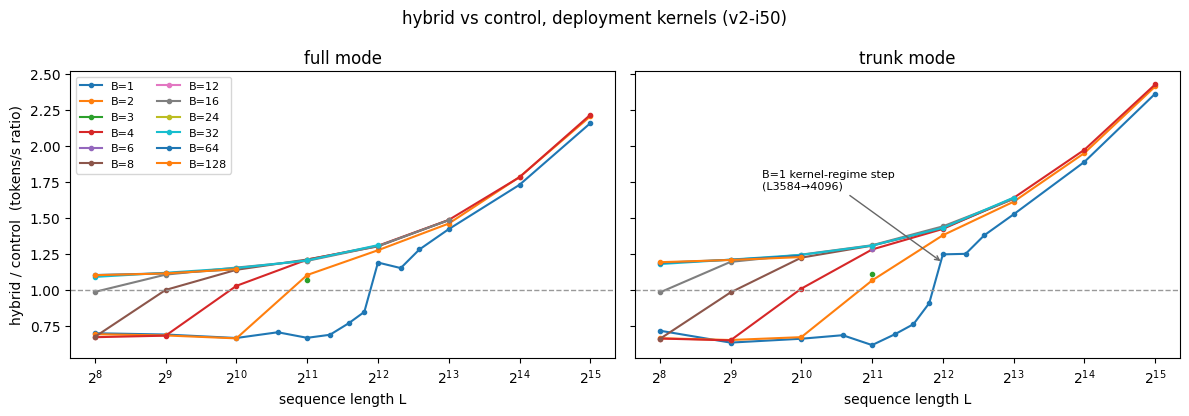

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, mode in zip(axes, ("full", "trunk")):
    sub = tier1[tier1["mode"] == mode]
    for b, g in sub.groupby("batch"):
        g = g.sort_values("length")
        ax.plot(g.length, g.ratio, marker="o", ms=3, label=f"B={b}")
    ax.axhline(1.0, color="0.6", lw=1, ls="--")
    ax.set_xscale("log", base=2)
    ax.set_title(f"{mode} mode"); ax.set_xlabel("sequence length L")
axes[0].set_ylabel("hybrid / control  (tokens/s ratio)")
axes[0].legend(fontsize=8, ncol=2)
axes[1].annotate("B=1 kernel-regime step\n(L3584→4096)", xy=(4096, 1.19),
                 xytext=(700, 1.7), fontsize=8,
                 arrowprops=dict(arrowstyle="->", color="0.4"))
fig.suptitle("hybrid vs control, deployment kernels (v2-i50)")
fig.tight_layout(); plt.show()

## 2. Kernel-arm robustness (hybrids only)
Deployment vs the three degraded arms at the slice points. Deployment should dominate
every bar group; the gaps attribute cost to the GDN axis vs the attention axis.

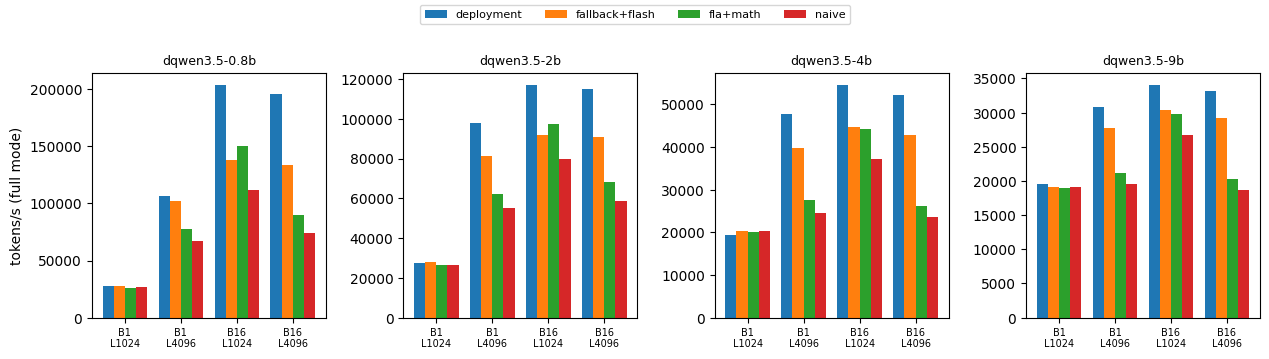

In [3]:
hybs = sorted(arms[arms.arm != "deployment"].model.unique())
order = ["deployment"] + sorted(a for a in arms.arm.unique() if a != "deployment")
pts = sorted(arms[["batch", "length"]].drop_duplicates().itertuples(index=False))
fig, axes = plt.subplots(1, len(hybs), figsize=(3.2 * len(hybs), 3.6), sharey=False)
for ax, m in zip(np.atleast_1d(axes), hybs):
    sub = arms[arms.model == m]
    x = np.arange(len(pts))
    for i, a in enumerate(order):
        y = [sub[(sub.arm == a) & (sub.batch == b) & (sub.length == L)].tokens_per_s.max()
             for b, L in pts]
        ax.bar(x + (i - 1.5) * 0.2, y, 0.2, label=a if m == hybs[0] else None)
    ax.set_xticks(x, [f"B{b}\nL{L}" for b, L in pts], fontsize=7)
    ax.set_title(m.replace("-base-v3", ""), fontsize=9)
axes[0].set_ylabel("tokens/s (full mode)")
fig.legend(loc="upper center", ncol=4, fontsize=8)
fig.tight_layout(rect=(0, 0, 1, 0.9)); plt.show()

## 3. Stability: why B=1 numbers get no third digit
Per-occasion deviation from each point's median (5 occasions: v1 + v2 + three repeats).
B=1 is launch-bound jitter; B≥4 reproduces sub-percent.

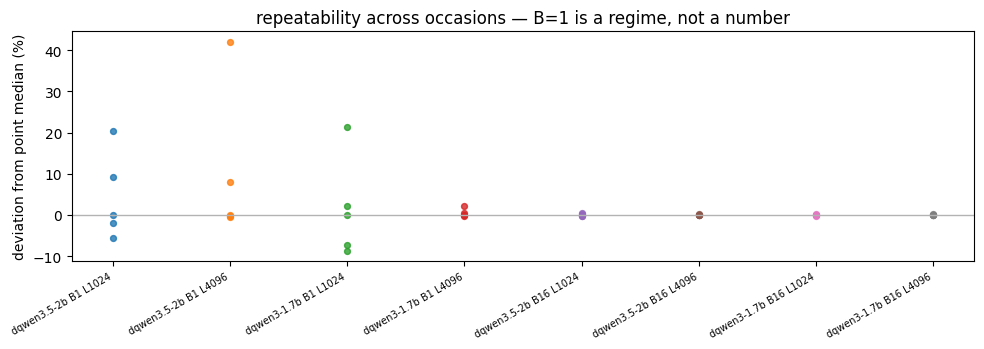

In [4]:
stab["key"] = stab.model.str.replace("-base(-v3)?$", "", regex=True) \
    + " B" + stab.batch.astype(str) + " L" + stab.length.astype(str)
stab["dev_pct"] = stab.groupby(["model", "batch", "length"]).median_ms \
    .transform(lambda s: 100 * (s - s.median()) / s.median())
fig, ax = plt.subplots(figsize=(10, 3.6))
keys = sorted(stab.key.unique(), key=lambda k: (int(k.split(" B")[1].split(" ")[0])))
for i, k in enumerate(keys):
    g = stab[stab.key == k]
    ax.scatter([i] * len(g), g.dev_pct, s=18, alpha=0.8)
ax.axhline(0, color="0.7", lw=1)
ax.set_xticks(range(len(keys)), keys, rotation=30, ha="right", fontsize=7)
ax.set_ylabel("deviation from point median (%)")
ax.set_title("repeatability across occasions — B=1 is a regime, not a number")
fig.tight_layout(); plt.show()

## 4. Nine-model context (deployment, full mode)
Left: saturated throughput (B16/L4096). Right: the launch-bound single-stream point.

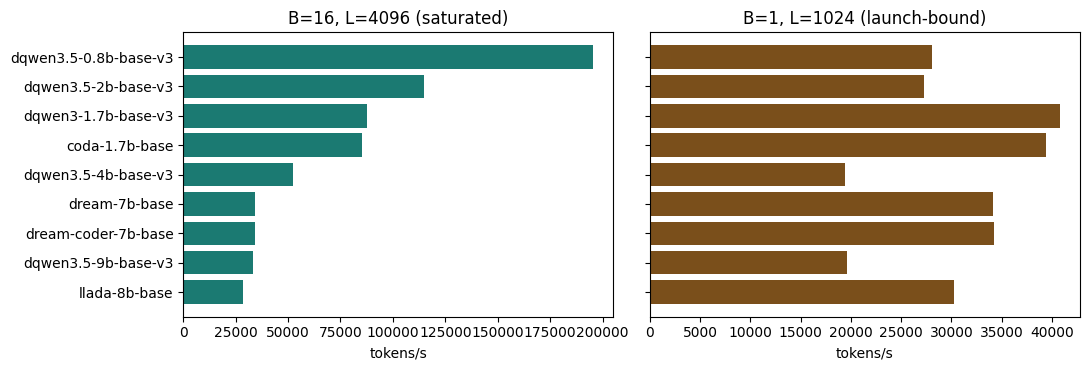

In [5]:
ms = msum.sort_values("b16_l4096_tok_s")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
axes[0].barh(ms.model, ms.b16_l4096_tok_s, color="#1b7a72")
axes[0].set_title("B=16, L=4096 (saturated)")
axes[1].barh(ms.model, ms.b1_l1024_tok_s, color="#7a4f1b")
axes[1].set_title("B=1, L=1024 (launch-bound)")
for ax in axes: ax.set_xlabel("tokens/s")
fig.tight_layout(); plt.show()

## 5. Trunk-mode memory scaling (the honest architecture memory story)
Full-mode memory is vocab-head-dominated — trunk mode is where attention-vs-GDN
activation scaling shows. (The prototype's "flatter memory" full-mode claim was refuted.)

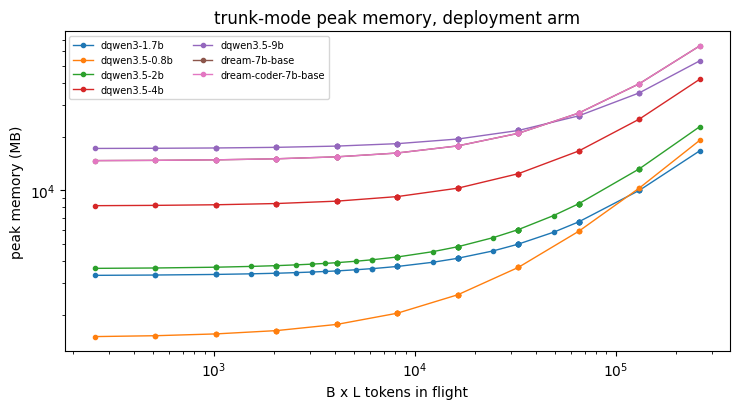

In [6]:
tr = v2[(v2["mode"] == "trunk") & (v2.arm == "deployment")].copy()
tr["tokens"] = tr.batch * tr.length
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for m, g in tr.groupby("model"):
    g = g.sort_values("tokens")
    ax.plot(g.tokens, g.peak_mem_mb, marker="o", ms=3, lw=1, label=m.replace("-base-v3", ""))
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("B x L tokens in flight"); ax.set_ylabel("peak memory (MB)")
ax.set_title("trunk-mode peak memory, deployment arm")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout(); plt.show()

## 6. Reviewer-defense extra: the both-naive ratio
Same Tier-1 ratio computed with BOTH models on reference kernels (math SDPA + GDN torch
fallback). It *grows* (fast kernels flatter the control) — the hybrid advantage is not
a kernel gift.

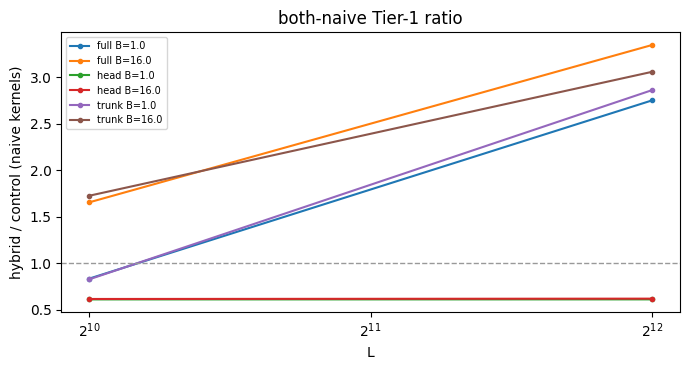

        min   max
mode             
full   0.84  3.34
head   0.61  0.62
trunk  0.83  3.06


In [7]:
nv = flat[(flat.arm == "naive") & flat.model.isin([HYB, CTL])
          & ~flat.oom & ~flat.unsupported]
piv = nv.pivot_table(index=["mode", "batch", "length"], columns="model",
                     values="tokens_per_s").dropna().reset_index()
piv["ratio"] = piv[HYB] / piv[CTL]
fig, ax = plt.subplots(figsize=(7, 3.8))
for (mode, b), g in piv.groupby(["mode", "batch"]):
    g = g.sort_values("length")
    ax.plot(g.length, g.ratio, marker="o", ms=3, label=f"{mode} B={b}")
ax.axhline(1.0, color="0.6", lw=1, ls="--")
ax.set_xscale("log", base=2)
ax.set_xlabel("L"); ax.set_ylabel("hybrid / control (naive kernels)")
ax.legend(fontsize=7); ax.set_title("both-naive Tier-1 ratio")
fig.tight_layout(); plt.show()
print(piv.groupby("mode").ratio.agg(["min", "max"]).round(2))